# **1. 준비된 Custom Dataset 가져오기**

**1-1. 데이터 가져오기**
- Nature.zip 파일 가져오기

In [1]:
!wget https://github.com/ayoolaolafenwa/PixelLib/releases/download/1.0.0/Nature.zip

--2026-03-09 11:17:21--  https://github.com/ayoolaolafenwa/PixelLib/releases/download/1.0.0/Nature.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/255074156/90ee5d00-eb46-11ea-9ed9-fa250c626244?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-09T12%3A09%3A19Z&rscd=attachment%3B+filename%3DNature.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-09T11%3A08%3A40Z&ske=2026-03-09T12%3A09%3A19Z&sks=b&skv=2018-11-09&sig=jt%2Bc2tsp9%2B5aUgyciGatPb%2FCc6uYbhL1KRgD%2BFDOAYk%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzA1Njg0MSwibmJmIjoxNzczMDU1MDQxLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvb

In [2]:
import zipfile

with zipfile.ZipFile('/content/Nature.zip') as target_file:
    target_file.extractall('/content/')

**1-2. .json 파일을 .txt 파일로 변환을 위해 labelme2yolo 설치**

In [3]:
# labelme2yolo 설치
!pip install labelme2yolo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 32.7 MB/s eta 0:00:00


**1-3. .json 파일을 .txt 파일로 변환**

In [4]:
# train dataset 준비
!labelme2yolo --json_dir '/content/Nature/train' --output_format polygon  # --output_format bbox 또는 polygon(default는 bbox)

[2026-03-09T11:18:09Z INFO  labelme2yolo] Starting the conversion process...
[2026-03-09T11:18:09Z INFO  labelme2yolo::yolo_dataset] Processing JSON files in streaming fashion...
⠁ [00:00:00] [Processing JSON files] 
⠁ [00:00:00] [Processing JSON files] Processed 300 files...
  [00:00:00] [Processing JSON files] Processed 600 files...
[2026-03-09T11:18:09Z INFO  labelme2yolo::yolo_dataset] Processed 600 JSON files.
[2026-03-09T11:18:09Z INFO  labelme2yolo::types] === Processing Summary ===
[2026-03-09T11:18:09Z INFO  labelme2yolo::types] Total files processed: 600
[2026-03-09T11:18:09Z INFO  labelme2yolo::types] Successful conversions: 600
[2026-03-09T11:18:09Z INFO  labelme2yolo::types] Skipped (missing image file): 0
[2026-03-09T11:18:09Z INFO  labelme2yolo::types] Skipped (no image data in JSON): 0
[2026-03-09T11:18:09Z INFO  labelme2yolo::types] Failed conversions: 0
[2026-03-09T11:18:09Z INFO  labelme2yolo::yolo_dataset] Processing background images...
[2026-03-09T11:18:09Z INFO  

In [5]:
!mv '/content/Nature/train/YOLODataset' '/content/train'

In [6]:
# test dataset 준비
!labelme2yolo --json_dir '/content/Nature/test' --output_format polygon  # --output_format bbox 또는 polygon(default는 bbox)

[2026-03-09T11:18:41Z INFO  labelme2yolo] Starting the conversion process...
[2026-03-09T11:18:41Z INFO  labelme2yolo::yolo_dataset] Processing JSON files in streaming fashion...
⠁ [00:00:00] [Processing JSON files] 
  [00:00:00] [Processing JSON files] Processed 200 files...
[2026-03-09T11:18:41Z INFO  labelme2yolo::yolo_dataset] Processed 200 JSON files.
[2026-03-09T11:18:41Z INFO  labelme2yolo::types] === Processing Summary ===
[2026-03-09T11:18:41Z INFO  labelme2yolo::types] Total files processed: 200
[2026-03-09T11:18:41Z INFO  labelme2yolo::types] Successful conversions: 200
[2026-03-09T11:18:41Z INFO  labelme2yolo::types] Skipped (missing image file): 0
[2026-03-09T11:18:41Z INFO  labelme2yolo::types] Skipped (no image data in JSON): 0
[2026-03-09T11:18:41Z INFO  labelme2yolo::types] Failed conversions: 0
[2026-03-09T11:18:41Z INFO  labelme2yolo::yolo_dataset] Processing background images...
[2026-03-09T11:18:41Z INFO  labelme2yolo::yolo_dataset] Background image processing comp

In [7]:
!mv '/content/Nature/test/YOLODataset' '/content/test'

# **2. Custom yaml 파일을 만들자.**

In [8]:
# PyYAML을 설치하자
!pip install PyYAML

In [9]:
import yaml

data_cf = {'train' : '/content/train/images/train',
           'val' : '/content/train/images/val',
           'names' : ["squirrel", "butterfly"],
           'nc' : 2 }

# fruit_data.yaml 이란 이름으로 custom yaml 파일을 만든다.
with open('/content/Nature_data.yaml', 'w') as f:
  yaml.dump(data_cf, f)

# fruit_data.yaml 확인
with open('/content/Nature_data.yaml', 'r') as f:
  Nature_yaml = yaml.safe_load(f)
  display(Nature_yaml)

{'names': ['squirrel', 'butterfly'],
 'nc': 2,
 'train': '/content/train/images/train',
 'val': '/content/train/images/val'}

# **3. YOLO26을 사용하기 위한 Setup(셋업)**

In [10]:
# ultralytics 설치
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.5 MB/s eta 0:00:00


In [11]:
# ultralytics 를 불러오고 체크
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)


# **4. Custom YOLO Training(학습)**

**Segmentation 모델로 사용할 수 있는 모델의 종류**

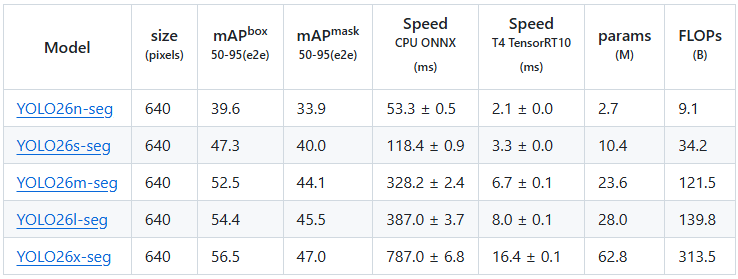

In [12]:
# ultralytics에서 YOLO 모듈을 불러옴
from ultralytics import YOLO
# yolo26n.pt 모델의 아키텍처와 가중치을 함께 불러옴
model = YOLO('yolo26n-seg.pt')

In [13]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell p

**불러온 모델 아키텍처를 이용하여 우리가 준비한 Custom Dataset으로 학습을 시켜보자.**

In [14]:
model.train(data='/content/Nature_data.yaml', epochs=100, patience=10, batch=16, imgsz=640)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Nature_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e62c5be1640>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

# **5. Training(학습) 결과 확인**

**학습 결과를 그래프로 저장한 파일을 통해 확인해 본다**

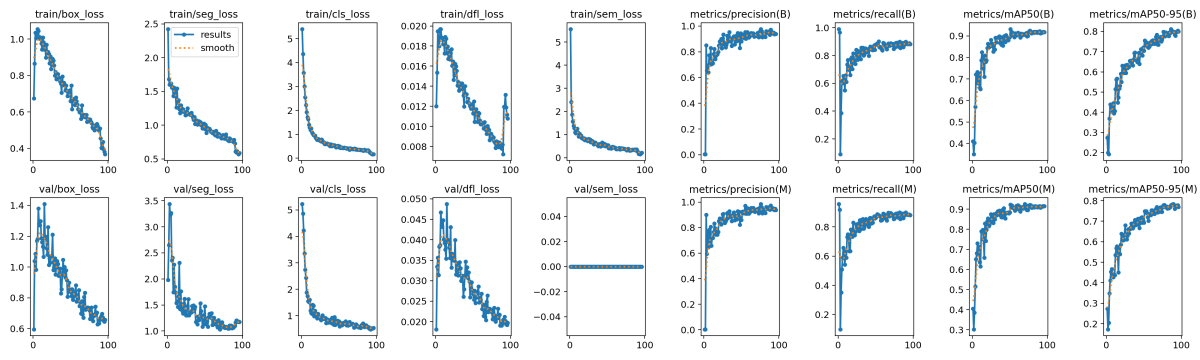

In [15]:
import cv2
from google.colab.patches import cv2_imshow

result_img = cv2.imread('/content/runs/segment/train/results.png')
fix_width = 1200
height,width = result_img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
result_img = cv2.resize(result_img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(result_img)

**Custom 모델이 분류할 수 있는 부류 확인**

In [16]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 2
{0: 'squirrel', 1: 'butterfly'}


# **6. Custom 모델로 Segmentation(분할)**

**Image Segmentation**

In [17]:
# 모델 예측
results = model.predict(source='/content/test/images/val/', save=True)


image 1/37 /content/test/images/val/__butterfly (21)_726f0645.jpg: 384x640 1 butterfly, 71.2ms
image 2/37 /content/test/images/val/__butterfly (25)_d02706e5.jpg: 416x640 1 butterfly, 70.1ms
image 3/37 /content/test/images/val/__butterfly (28)_c6fde2ea.jpg: 512x640 1 butterfly, 68.8ms
image 4/37 /content/test/images/val/__butterfly (29)_9154a86e.jpg: 640x480 1 butterfly, 67.6ms
image 5/37 /content/test/images/val/__butterfly (3)_5cdb933d.jpg: 384x640 1 butterfly, 11.8ms
image 6/37 /content/test/images/val/__butterfly (30)_ba45aeaa.jpg: 640x640 1 butterfly, 12.6ms
image 7/37 /content/test/images/val/__butterfly (39)_cf3c8e6a.jpg: 512x640 1 butterfly, 16.3ms
image 8/37 /content/test/images/val/__butterfly (4)_4bf2082d.jpg: 448x640 1 butterfly, 79.9ms
image 9/37 /content/test/images/val/__butterfly (40)_b8a9c57a.jpg: 480x640 1 butterfly, 68.7ms
image 10/37 /content/test/images/val/__butterfly (41)_d3496791.jpg: 640x640 1 butterfly, 12.5ms
image 11/37 /content/test/images/val/__butterfly (

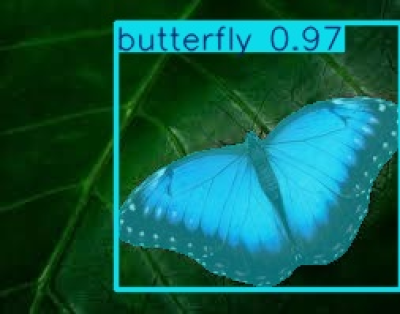

In [19]:
# 예측 이미지 확인
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/runs/segment/predict/__butterfly (39)_cf3c8e6a.jpg')
fix_width = 400
height,width = img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
img = cv2.resize(img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(img)

**Video Segmentation**

In [21]:
# 동영상 예측
results = model.predict(source='/content/butterfly.mp4', save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/903) /content/butterfly.mp4: 384x640 1 butterfly, 12.9ms
video 1/1 (frame 2/903) /content/butterfly.mp4: 384x640 1 butterfly, 13.7ms
video 1/1 (frame 3/903) /content/butterfly.mp4: 384x640 1 butterfly, 15.1ms
video 1/1 (frame 4/903) /content/butterfly.mp4: 384x640 1 butterfly, 15.3ms
video 1/1 (frame 5/903) /content/butterfly.mp4: 384x640 1 butterfly, 14.4ms
video 1/1 (frame 6/903) /content/butterfly.mp4: 384x640 1 butterfly, 13.2ms
vi

In [22]:
# 코랩에서 영상을 보여줄 준비
import io
from IPython.display import HTML
from base64 import b64encode
def show_video(file_name, width=640):
  # show resulting deepsort video
  mp4 = open(file_name,'rb').read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
  return HTML("""
  <video width="{0}" controls>
        <source src="{1}" type="video/mp4">
  </video>
  """.format(width, data_url))

In [23]:
# avi 파일을 mp4 파일로 변환 후 영상을 보여줌
import os
path_video = os.path.join("runs/segment/predict","butterfly.avi")
%cd runs/segment/predict
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!ffmpeg -y -loglevel panic -i "butterfly.avi" "butterfly.mp4"
%cd ../../../

# output object tracking video
path_output = os.path.join("runs/segment/predict","butterfly.mp4")
show_video(path_output, width=640)

Output hidden; open in https://colab.research.google.com to view.

# **7. 학습된 모델을 불러와 분할**

In [24]:
# ultralytics 설치
!pip install ultralytics

# ultralytics 를 불러오고 체크
import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.8/112.6 GB disk)


In [25]:
# ultralytics에서 YOLO 모듈을 불러옴
from ultralytics import YOLO
# 학습된 모델의 아키텍처와 가중치을 함께 불러옴
model = YOLO('/content/runs/segment/train/weights/best.pt')

In [26]:
# 모델이 분류할 수 있는 부류의 수 확인
print(type(model.names), len(model.names))
# 모델이 분류할 수 있는 부류 확인
print(model.names)

<class 'dict'> 2
{0: 'squirrel', 1: 'butterfly'}


In [30]:
# 모델 예측
results = model.predict(source='/content/test/images/val/__imagesbutterfly (61)_3c24bc04.jpg', save=True)


image 1/1 /content/test/images/val/__imagesbutterfly (61)_3c24bc04.jpg: 288x640 1 butterfly, 26.8ms
Speed: 2.4ms preprocess, 26.8ms inference, 3.7ms postprocess per image at shape (1, 3, 288, 640)
Results saved to /content/runs/segment/predict2


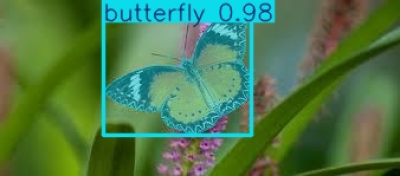

In [31]:
# 예측 이미지 확인
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/runs/segment/predict2/__imagesbutterfly (61)_3c24bc04.jpg')
fix_width = 400
height,width = img.shape[:2]
ratio = fix_width / width
demension = (fix_width, int(height*ratio))
img = cv2.resize(img, demension, interpolation=cv2.INTER_AREA)
cv2_imshow(img)